## Continuação da aula 26/11

In [18]:
import numpy as np
import numpy.random as rd
import matplotlib.pyplot as plt
import sklearn.datasets as dt
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, precision_recall_curve
import pickle
from sklearn.ensemble import RandomForestClassifier
import scipy.spatial.distance as spd
import sklearn.preprocessing as pp
from sklearn.decomposition import PCA
import numpy.linalg as la
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_extraction.text import CountVectorizer

In [19]:
fn = 'data/imdbFull.p'

D = pickle.load(open(fn, 'rb'))
docList = D['data']
docList = np.array(docList)
y = D['target']

In [20]:
docList = [re.sub(r'[^a-zA-Z]+', ' ', doc) for doc in docList]
print(docList[3])

There are a lot of highly talented filmmakers actors in Germany now None of them are associated with this movie br br Why in the world do producers actually invest money in something like this this You could have made good films with the budget of this garbage It s not entertaining to have seven grown men running around as dwarfs pretending to be funny What IS funny though is that the film s producer who happens to be the oldest guy of the bunch is playing the YOUNGEST dwarf br br The film is filled with moments that scream for captions saying You re supposed to laugh now It s hard to believe that this crap s supposed to be a comedy br br Many people actually stood up and left the cinema minutes into the movie I should have done the same instead of wasting my time br br Pain 


In [21]:
tfidf = TfidfVectorizer().fit(docList)
voc = tfidf.get_feature_names_out()
print(voc.shape)

(99400,)


In [22]:
snowB = SnowballStemmer("english")
a = docList[0]
a.split(' ')

['Zero',
 'Day',
 'leads',
 'you',
 'to',
 'think',
 'even',
 're',
 'think',
 'why',
 'two',
 'boys',
 'young',
 'men',
 'would',
 'do',
 'what',
 'they',
 'did',
 'commit',
 'mutual',
 'suicide',
 'via',
 'slaughtering',
 'their',
 'classmates',
 'It',
 'captures',
 'what',
 'must',
 'be',
 'beyond',
 'a',
 'bizarre',
 'mode',
 'of',
 'being',
 'for',
 'two',
 'humans',
 'who',
 'have',
 'decided',
 'to',
 'withdraw',
 'from',
 'common',
 'civility',
 'in',
 'order',
 'to',
 'define',
 'their',
 'own',
 'mutual',
 'world',
 'via',
 'coupled',
 'destruction',
 'br',
 'br',
 'It',
 'is',
 'not',
 'a',
 'perfect',
 'movie',
 'but',
 'given',
 'what',
 'money',
 'time',
 'the',
 'filmmaker',
 'and',
 'actors',
 'had',
 'it',
 'is',
 'a',
 'remarkable',
 'product',
 'In',
 'terms',
 'of',
 'explaining',
 'the',
 'motives',
 'and',
 'actions',
 'of',
 'the',
 'two',
 'young',
 'suicide',
 'murderers',
 'it',
 'is',
 'better',
 'than',
 'Elephant',
 'in',
 'terms',
 'of',
 'being',
 'a',
 '

In [23]:
b = [snowB.stem(w) for w in a.split(' ')]
print(b)

['zero', 'day', 'lead', 'you', 'to', 'think', 'even', 're', 'think', 'whi', 'two', 'boy', 'young', 'men', 'would', 'do', 'what', 'they', 'did', 'commit', 'mutual', 'suicid', 'via', 'slaughter', 'their', 'classmat', 'it', 'captur', 'what', 'must', 'be', 'beyond', 'a', 'bizarr', 'mode', 'of', 'be', 'for', 'two', 'human', 'who', 'have', 'decid', 'to', 'withdraw', 'from', 'common', 'civil', 'in', 'order', 'to', 'defin', 'their', 'own', 'mutual', 'world', 'via', 'coupl', 'destruct', 'br', 'br', 'it', 'is', 'not', 'a', 'perfect', 'movi', 'but', 'given', 'what', 'money', 'time', 'the', 'filmmak', 'and', 'actor', 'had', 'it', 'is', 'a', 'remark', 'product', 'in', 'term', 'of', 'explain', 'the', 'motiv', 'and', 'action', 'of', 'the', 'two', 'young', 'suicid', 'murder', 'it', 'is', 'better', 'than', 'eleph', 'in', 'term', 'of', 'be', 'a', 'film', 'that', 'get', 'under', 'our', 'rationalist', 'skin', 'it', 'is', 'a', 'far', 'far', 'better', 'film', 'than', 'almost', 'anyth', 'you', 'are', 'like',

In [24]:
b = ' '.join(b) # Junta todas as palavras da lista separadas por um espaço
print(b)

zero day lead you to think even re think whi two boy young men would do what they did commit mutual suicid via slaughter their classmat it captur what must be beyond a bizarr mode of be for two human who have decid to withdraw from common civil in order to defin their own mutual world via coupl destruct br br it is not a perfect movi but given what money time the filmmak and actor had it is a remark product in term of explain the motiv and action of the two young suicid murder it is better than eleph in term of be a film that get under our rationalist skin it is a far far better film than almost anyth you are like to see br br flaw but honest with a terribl honesti 


In [25]:
Ds = []

for doc in docList[:10]:
    Ds.append(' '.join([snowB.stem(w) for w in doc.split(' ')]))

print(len(Ds))
print(Ds[1])

10
word can t describ how bad this movi is i can t explain it by write onli you have too see it for yourself to get at grip of how horribl a movi realli can be not that i recommend you to do that there are so mani clich s mistak and all other negat thing you can imagin here that will just make you cri to start with the technic first there are a lot of mistak regard the airplan i won t list them here but just mention the color of the plane they didn t even manag to show an airlin in the color of a fiction airlin but instead use a paint in the origin boe liveri veri bad the plot is stupid and has been done mani time befor onli much much better there are so mani ridicul moment here that i lost count of it realli earli also i was on the bad guy side all the time in the movi becaus the good guy were so stupid execut decis should without a doubt be you re choic over this one even the turbul movi are better in fact everi other movi in the world is better than this one 


In [26]:
Ds = []

for doc in docList:
    Ds.append(' '.join([snowB.stem(w) for w in doc.split(' ')]))

In [27]:
len(Ds)

50000

In [28]:
tfidf = TfidfVectorizer().fit(Ds)
voc = tfidf.get_feature_names_out()
voc.shape

(68269,)

In [29]:
tfidf = TfidfVectorizer(min_df=5).fit(Ds)
voc = tfidf.get_feature_names_out()
voc.shape

(24032,)

In [30]:
tfidf = TfidfVectorizer(min_df=5, max_features=5000).fit(Ds)
X = tfidf.transform(Ds)
X.shape

(50000, 5000)

In [31]:
yb = (y > 5) * 1
print(np.unique(yb))

[0 1]


In [32]:
X1, X2, y1, y2 = train_test_split(X, yb, test_size=1/3, random_state=42, stratify=y)
lr = LogisticRegression().fit(X1, y1)
y2e = lr.predict(X2)
print(confusion_matrix(y2, y2e))

[[7368  965]
 [ 871 7463]]


In [33]:
print(np.sum(y2 != y2e))
print(np.sum(y2 != y2e) / y2.shape[0]) # 11% de erros

1836
0.11015779684406311


In [34]:
tfidf = TfidfVectorizer(min_df=5, max_features=20000).fit(Ds)
X = tfidf.transform(Ds)
X.shape

(50000, 20000)

In [35]:
X1, X2, y1, y2 = train_test_split(X, yb, test_size=1/3, random_state=42, stratify=y)
lr = LogisticRegression().fit(X1, y1)
y2e = lr.predict(X2)
print(confusion_matrix(y2, y2e))

[[7382  951]
 [ 841 7493]]


In [36]:
print(np.sum(y2 != y2e) / y2.shape[0]) # 10% de erros

0.10751784964300715


In [37]:
w = lr.coef_
print(w.shape)

(1, 20000)


In [38]:
w = w.squeeze() # flatten também resulta
print(w.shape)

(20000,)


In [39]:
idx = np.argsort(w)
print(voc[idx[:10]]) # valores mais negativos
print('\n', voc[idx[-10:]]) # valores mais positivos

['soooooo' 'atrophi' 'sj' 'asleep' 'milian' 'bickford' 'rhame' 'croon'
 'downward' 'litel']

 ['equival' 'conting' 'furr' 'blondi' 'dippi' 'infomerci' 'bask' 'maximum'
 'dogg' 'fey']


In [40]:
voc = tfidf.get_feature_names_out()
voc.shape

(20000,)

In [41]:
print(voc[idx[:50]])
print('\n', voc[idx[-50:]])

['worst' 'bad' 'wast' 'aw' 'poor' 'bore' 'terribl' 'disappoint' 'fail'
 'noth' 'horribl' 'suppos' 'dull' 'wors' 'save' 'stupid' 'unfortun'
 'annoy' 'lack' 'no' 'minut' 'instead' 'lame' 'unless' 'script' 'avoid'
 'pointless' 'onli' 'mess' 'ridicul' 'oh' 'clich' 'mediocr' 'laughabl'
 'predict' 'whi' 'pathet' 'cheap' 'even' 'embarrass' 'couldn' 'tri'
 'sorri' 'tedious' 'just' 'unfunni' 'attempt' 'redeem' 'money' 'bother']

 ['greatest' 'job' 'see' 'wonder' 'simpl' 'marvel' 'classic' 'human'
 'refresh' 'you' 'bit' 'perform' 'alway' 'gem' 'realist' 'solid' 'good'
 'especi' 'funniest' 'recommend' 'also' 'and' 'veri' 'awesom' 'strong'
 'delight' 'touch' 'entertain' 'surpris' 'fantast' 'dvd' 'still' 'appreci'
 'it' 'superb' 'amaz' 'well' 'favorit' 'beauti' 'today' 'fun' 'definit'
 'hilari' 'brilliant' 'enjoy' 'love' 'best' 'perfect' 'excel' 'great']


In [42]:
lr = LogisticRegression(penalty='l1', solver='saga').fit(X1, y1)

In [43]:
w = lr.coef_
w = w.squeeze()
print(w.shape)

(20000,)


In [44]:
idx = np.argsort(w)
print(voc[idx[:10]]) # valores mais negativos

['worst' 'wast' 'aw' 'poor' 'bore' 'bad' 'fail' 'terribl' 'horribl' 'dull']


In [45]:
y2e = lr.predict(X2)
print(confusion_matrix(y2, y2e))

[[7303 1030]
 [ 883 7451]]


In [46]:
print(np.sum(y2 != y2e) / y2.shape[0]) # 11% de erros
print(np.sum(w == 0)) # número de pesos iguais a zero

0.11477770444591108
18881


In [47]:
X.shape[1] - np.sum(w == 0)
idx = (w != 0)
a = voc[idx] # palavras com peso diferente de zero
print(a.shape)
print(a[:100])

(1119,)
['abc' 'abl' 'accent' 'accomplish' 'achiev' 'act' 'action' 'actor'
 'actress' 'addict' 'ador' 'adventur' 'advic' 'ago' 'aim' 'air' 'alex'
 'along' 'alreadi' 'alright' 'also' 'although' 'alway' 'am' 'amateur'
 'amateurish' 'amaz' 'america' 'amus' 'and' 'ani' 'annoy' 'anoth' 'ant'
 'anyon' 'anyth' 'anyway' 'ape' 'appal' 'appar' 'appeal' 'appear'
 'appreci' 'aren' 'as' 'asham' 'asleep' 'astair' 'atlanti' 'atmospher'
 'attempt' 'attent' 'attract' 'audienc' 'australian' 'authent' 'avail'
 'avoid' 'aw' 'awesom' 'back' 'bad' 'baldwin' 'barbara' 'bare' 'barney'
 'basic' 'batman' 'be' 'beach' 'beauti' 'becaus' 'becom' 'bed' 'been'
 'befor' 'behav' 'behavior' 'belong' 'below' 'ben' 'best' 'better' 'betti'
 'beyond' 'bibl' 'big' 'biggest' 'biko' 'bilko' 'bin' 'bit' 'blade' 'blah'
 'blame' 'bland' 'blatant' 'blend' 'blond' 'blood']


In [48]:
lr = LogisticRegression(penalty='l1', solver='saga', C=10).fit(X1, y1)
w = lr.coef_
w = w.squeeze()
X.shape[1] - np.sum(w == 0)
idx = (w != 0)
a= voc[idx]

#Fazer com que não use tante regularização
lr = LogisticRegression(penalty='l1', solver='saga', C=10).fit(X1, y1)

w = lr.coef_
np.sum(w == 0)
X.shape[1] - np.sum(w == 0)

y2e = lr.predict(X2)
confusion_matrix(y2, y2e)
print(np.sum(y2 != y2e) / y2.shape[0])

c:\Users\rui\OneDrive - Instituto Politécnico de Lisboa\Faculdade\3º Ano\AA\codigo\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


0.11597768044639108


c:\Users\rui\OneDrive - Instituto Politécnico de Lisboa\Faculdade\3º Ano\AA\codigo\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [49]:
D = dt.load_breast_cancer()
X = D.data
y = D.target

y = np.abs(y-1)

X1, X2, y1, y2 = train_test_split(X, y, test_size=1/3, random_state=42, stratify=y)

In [50]:
fnames = D.feature_names
print(fnames)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [51]:
lr = LogisticRegression(penalty='l2', C=1.0, max_iter=5000).fit(X1, y1)

In [52]:
w = lr.coef_
print(w)

[[-0.99194133 -0.26876506  0.2153243  -0.02022574  0.14225609  0.21694457
   0.41724512  0.22171456  0.19081778  0.03465836  0.07210753 -1.23192235
   0.29423284  0.09777976  0.01732402 -0.03271517  0.03926997  0.02727106
   0.03783294 -0.00605527 -0.16713288  0.56159295  0.09293914  0.01501852
   0.23367529  0.56610516  1.00628061  0.39349293  0.66301861  0.08701844]]


In [53]:
idx = np.argsort(w)
w = w.squeeze()
w[idx]

array([[-1.23192235, -0.99194133, -0.26876506, -0.16713288, -0.03271517,
        -0.02022574, -0.00605527,  0.01501852,  0.01732402,  0.02727106,
         0.03465836,  0.03783294,  0.03926997,  0.07210753,  0.08701844,
         0.09293914,  0.09777976,  0.14225609,  0.19081778,  0.2153243 ,
         0.21694457,  0.22171456,  0.23367529,  0.29423284,  0.39349293,
         0.41724512,  0.56159295,  0.56610516,  0.66301861,  1.00628061]])

In [54]:
print([fnames[i] for i in idx[:5]])

[array(['texture error', 'mean radius', 'mean texture', 'worst radius',
       'compactness error', 'mean area', 'fractal dimension error',
       'worst area', 'smoothness error', 'concave points error',
       'mean fractal dimension', 'symmetry error', 'concavity error',
       'radius error', 'worst fractal dimension', 'worst perimeter',
       'area error', 'mean smoothness', 'mean symmetry', 'mean perimeter',
       'mean compactness', 'mean concave points', 'worst smoothness',
       'perimeter error', 'worst concave points', 'mean concavity',
       'worst texture', 'worst compactness', 'worst symmetry',
       'worst concavity'], dtype='<U23')]


In [55]:
lr = LogisticRegression(penalty='l1', solver='saga', C=1, max_iter=5000).fit(X1, y1)

In [56]:
w = lr.coef_.squeeze()
w

array([-1.63819163e-02,  1.94358517e-03, -8.09046326e-02, -1.65699910e-02,
        0.00000000e+00,  1.01080730e-04,  4.80689703e-04,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00, -4.29721484e-04,
        2.10317855e-03,  3.22225591e-02,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -1.68122615e-02,  1.15720166e-02, -6.08842769e-02,  2.84560589e-02,
        0.00000000e+00,  1.50896257e-03,  2.13557490e-03,  2.29558850e-04,
        4.91951000e-06,  0.00000000e+00])

In [57]:
np.sum(w == 0)

np.int64(13)

In [66]:
y2e = lr.predict(X2)
confusion_matrix(y2, y2e)

array([[119,   0],
       [ 12,  59]])

In [67]:
print(np.sum(y2 != y2e) / y2.shape[0] * 100)

6.315789473684211


In [71]:
y2d = lr.decision_function(X2)
confusion_matrix(y2, y2d>-2)

array([[95, 24],
       [ 4, 67]])

(np.float64(-0.05), np.float64(1.05), np.float64(-0.05), np.float64(1.05))

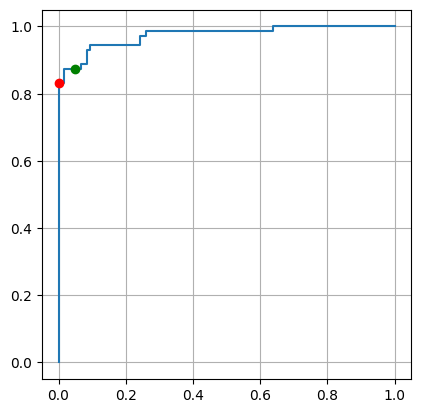

In [85]:
fp, tp, t = roc_curve(y2, y2d)
plt.plot(fp, tp)
plt.plot(0, 59/(59+12), 'or')
plt.plot(6/119, 62/71, 'og')
plt.grid(True)
plt.axis('scaled')

In [87]:
lr = LogisticRegression(penalty='l1', solver='saga', C=10.0, max_iter=5000).fit(X1, y1)

In [88]:
w = lr.coef_.squeeze()
w

array([-1.69759579e-02,  2.23633823e-03, -8.17041809e-02, -1.65478389e-02,
        1.28101615e-06,  5.29947351e-04,  9.40837516e-04,  3.56609932e-04,
       -8.02578010e-05, -2.99378831e-05, -3.11894421e-05, -8.52527359e-04,
        2.52272862e-03,  3.27493373e-02,  0.00000000e+00,  8.45175508e-05,
        1.34062031e-04,  3.60888416e-06,  0.00000000e+00,  0.00000000e+00,
       -1.74074026e-02,  1.25585772e-02, -6.10299778e-02,  2.85109625e-02,
        4.52281728e-05,  1.99751097e-03,  2.64464474e-03,  6.84290621e-04,
        2.04971600e-04,  6.28266681e-05])

In [89]:
y2e = lr.predict(X2)
confusion_matrix(y2, y2e)

array([[119,   0],
       [ 12,  59]])

np.int64(3)

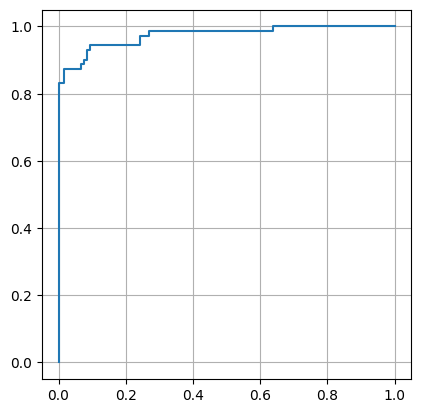

In [91]:
y2d = lr.decision_function(X2)
fp, tp, t = roc_curve(y2, y2d)
plt.plot(fp, tp)
plt.grid(True)
plt.axis('scaled')
np.sum(w==0)

In [94]:
D = dt.load_iris()
X = D.data
y = D.target

X1, X2, y1, y2 = train_test_split(X, y, test_size=1/3, random_state=42, stratify=y)

In [95]:
lr = LogisticRegression(penalty='l1', solver='saga', C=0.1, max_iter=5000).fit(X1, y1)

In [96]:
y2e = lr.predict(X2)
confusion_matrix(y2, y2e)

array([[16,  0,  0],
       [ 0, 16,  1],
       [ 0,  2, 15]])

In [97]:
w = lr.coef_.squeeze()
w

array([[ 0.        ,  0.        , -1.42531572,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  1.16366676,  0.        ]])

In [99]:
D.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [101]:
w0 = lr.intercept_
w0

array([ 4.65823265,  0.49719039, -5.15542304])